In [1]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
# import geopandas as gpd
# from shapely.geometry import Point

from tqdm import tqdm
import os
import shutil
import tempfile
import logging
import geopandas as gpd
import rioxarray as rxr

In [2]:
# LDD direction convention (PCRaster):
# 7 8 9
# 4 5 6
# 1 2 3
# For each direction, what is the (row_offset, col_offset) of the downstream neighbour?
# e.g. direction 1 means flow goes to bottom-left → downstream is at (+1, -1)

# Inverse: for each neighbour position, which LDD value points TO the current cell?
# neighbour at (-1, -1) has direction 3 if it flows to us
# neighbour at (-1,  0) has direction 2
# neighbour at (-1, +1) has direction 1
# neighbour at ( 0, -1) has direction 6
# neighbour at ( 0, +1) has direction 4
# neighbour at (+1, -1) has direction 9
# neighbour at (+1,  0) has direction 8
# neighbour at (+1, +1) has direction 7

# (row_offset, col_offset) -> LDD value that points toward current cell
UPSTREAM_DIRS = {
    (-1, -1): 3,
    (-1,  0): 2,
    (-1, +1): 1,
    ( 0, -1): 6,
    ( 0, +1): 4,
    ( 1, -1): 9,
    ( 1,  0): 8,
    ( 1, +1): 7,
}

def cutmaps_own(ldd_array, lon_array, lat_array, station_lon, station_lat):
    """
    Trace upstream from station pixel through LDD to get catchment mask.
    Returns a 2D boolean array (same shape as ldd_array).
    """
    # find nearest pixel to station coordinates
    col = np.argmin(np.abs(lon_array - station_lon))
    row = np.argmin(np.abs(lat_array - station_lat))
    # print(f"  Station pixel: row={row}, col={col}, lon={lon_array[col]:.3f}, lat={lat_array[row]:.3f}")

    nrows, ncols = ldd_array.shape
    mask = np.zeros((nrows, ncols), dtype=bool)

    # BFS upstream flood-fill
    queue = [(row, col)]
    mask[row, col] = True

    while queue:
        r, c = queue.pop()
        for (dr, dc), upstream_val in UPSTREAM_DIRS.items():
            nr, nc = r + dr, c + dc
            if 0 <= nr < nrows and 0 <= nc < ncols:
                if not mask[nr, nc] and ldd_array[nr, nc] == upstream_val:
                    mask[nr, nc] = True
                    queue.append((nr, nc))

    return mask

In [ ]:
BASE_FILE = Path.cwd () / "GloFASv5_stations_metadata_calfunction_KGE_JSD_20March2026_final.csv"
# Folder with static attributes
DIR_STATIC = Path("/mnt/eos_rw/projects/FLOODS-RIVER/schafti/02_GloFAS_EFAS/GloFAS/GloFASv5/static_maps/GloFASv5_staticmaps_consolidated_March2026/GloFASv5_static_maps_reanalysis/")

# Base File
glofas5_base_info = pd.read_csv(BASE_FILE)

# Glacier File
GLFILE = Path("/mnt/eos_rw/projects/FLOODS-RIVER/schafti/01_GIS/02_Glacier/RGI_V7/global_mask.gpkg")

In [ ]:
# station list
cal_stations = glofas5_base_info[["LISFLOOD_X","LISFLOOD_Y", "ID"]].values
if not (DIR_STATIC / "cal_stations.txt").exists():
    with open(DIR_STATIC / "cal_stations.txt", "w") as f:
        for x, y, id_ in cal_stations:
            f.write(f"{x:.3f}  {y:.3f}\t{int(id_)}\n")

In [ ]:
# glacier infos
glaciers = gpd.read_file(GLFILE)

### Load ldd & uparea

In [7]:
# Load LDD file
ldd_nc = DIR_STATIC / "ldd_repaired.nc"
ds_ldd = xr.open_dataset(ldd_nc)
print("\n=== ldd_repaired.nc ===")
print(ds_ldd)
print("\n=== Variables & dtypes ===")
for var in ds_ldd.data_vars:
    print(f"{var}: {ds_ldd[var].dtype}")
ds_ldd.close()

# Load upArea file
uparea_nc = DIR_STATIC / "upArea_repaired_correctedmetadata_3000.nc"
ds_uparea = xr.open_dataset(uparea_nc)
print("\n=== upArea_repaired_correctedmetadata_3000.nc ===")
print(ds_uparea)
print("\n=== Variables & dtypes ===")
for var in ds_uparea.data_vars:
    print(f"{var}: {ds_uparea[var].dtype}")
ds_uparea.close()


=== ldd_repaired.nc ===
<xarray.Dataset> Size: 86MB
Dimensions:  (lat: 3000, lon: 7200)
Coordinates:
  * lat      (lat) float64 24kB 89.97 89.92 89.88 89.82 ... -59.88 -59.92 -59.97
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      |S1 1B ...
    Band1    (lat, lon) float32 86MB ...
Attributes:
    CDI:                        Climate Data Interface version 1.9.10 (https:...
    Conventions:                CF-1.5
    GDAL_AREA_OR_POINT:         Area
    GDAL_PCRASTER_VALUESCALE:   VS_LDD
    GDAL:                       GDAL 3.2.1, released 2020/12/29
    CDO:                        Climate Data Operators version 1.9.10 (https:...
    history:                    Fri Dec 10 11:49:28 2021: ncks -A -v lat,lon ...
    history_of_appended_files:  Fri Dec 10 11:49:28 2021: Appended file ldd_O...
    NCO:                        netCDF Operators version 4.9.7 (Homepage = ht...

=== Variables & dtypes ===
crs: |S1
Band1: float32

=== upArea_r

### create glacier mask

In [33]:
glmask = xr.ones_like(ds_ldd).astype(float)
original_attrs = glmask.attrs  # save before operations drop them

glmask = glmask.rio.write_crs("EPSG:4326")
glmask = glmask.rio.clip(glaciers.geometry, drop=False, all_touched=True)
glmask = xr.where(glmask.isnull() & ds_ldd['Band1'].notnull(), 0.0, glmask)
# restore attrs + add description
glmask.attrs = original_attrs | {"description": "Glacier mask: 1=glacier, 0=land, NaN=ocean"}

In [35]:
# Store GloFASv5 & RGIv7 based Glacier Dataset
glmask.to_netcdf(DIR_STATIC / "glaciers_Global_03min.nc")

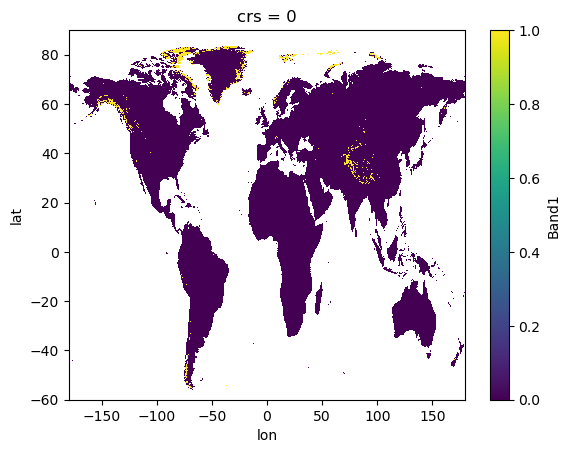

In [29]:
glmask.Band1.plot()

### loop over all catchments & assign glacier coverage

In [40]:
"""
catchment_glacier_fraction.py
------------------------------
Extracts glacier fraction for all GloFAS calibration stations
using BFS upstream tracer on LDD + RGI glacier shapefile.
"""

import time
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rioxarray
from pathlib import Path
from tqdm import tqdm

# =============================================================================
# STEP 0 — load LDD, pixel area, compute glacier mask
# =============================================================================

PIXAREA_NC = DIR_STATIC / "pixarea_Global_03min.nc"

print("Loading pixel area...")
ds_area    = xr.open_dataset(PIXAREA_NC)
area_array = np.squeeze(ds_area[list(ds_area.data_vars)[-1]].values)
area_lon   = ds_area.lon.values
area_lat   = ds_area.lat.values

print("Loading ldd...")
ldd_array = np.squeeze(ds_ldd['Band1'].values)
lon_array = ds_ldd.lon.values
lat_array = ds_ldd.lat.values
print(f"LDD shape: {ldd_array.shape}")

# 1.0 inside glacier, 0.0 outside, Nan in Oceans etc.
glacier_array = glmask['Band1'].values
print(f"Glacier pixels: {glacier_array.sum():.0f} of {glacier_array.size}")

# =============================================================================
# STEP 1+2 — loop over stations: BFS mask → glacier fraction
# =============================================================================

cal_stations = glofas5_base_info[["LISFLOOD_X", "LISFLOOD_Y", "ID"]].values
results = []
t_total = time.time()

for x, y, station_id in tqdm(cal_stations, desc="Processing stations"):
    station_id = int(station_id)
    row = {"ID": station_id}

    # BFS catchment mask
    mask = cutmaps_own(ldd_array, lon_array, lat_array, x, y)

    rows_idx, cols_idx = np.where(mask)
    if len(rows_idx) == 0:
        row["glacier_frac"] = np.nan
        results.append(row)
        continue

    r_min, r_max = rows_idx.min(), rows_idx.max()
    c_min, c_max = cols_idx.min(), cols_idx.max()
    mask_cut = mask[r_min:r_max+1, c_min:c_max+1]

    bbox_lon = lon_array[[c_min, c_max]]
    bbox_lat = lat_array[[r_min, r_max]]

    # cut glacier array to bbox
    glacier_cut = glacier_array[r_min:r_max+1, c_min:c_max+1]  # same grid as LDD, no argmin needed

    # cut area array to bbox
    ac_min = np.argmin(np.abs(area_lon - bbox_lon[0]))
    ac_max = np.argmin(np.abs(area_lon - bbox_lon[1]))
    ar_min = np.argmin(np.abs(area_lat - bbox_lat[0]))
    ar_max = np.argmin(np.abs(area_lat - bbox_lat[1]))
    area_cut = area_array[ar_min:ar_max+1, ac_min:ac_max+1]

    # apply catchment mask
    glacier_vals = glacier_cut[mask_cut].astype(float)  # 0s and 1s for upstream pixels

    # area-weighted glacier fraction
    if area_cut.shape == mask_cut.shape:
        w     = area_cut[mask_cut].astype(float)
        w     = np.where(np.isfinite(w), w, 0.0)
        w_sum = w.sum()
        row["glacier_frac"] = float(np.sum(glacier_vals * w) / w_sum) if w_sum > 0 else float(np.mean(glacier_vals))
    else:
        row["glacier_frac"] = float(np.mean(glacier_vals))

    results.append(row)

print(f"\nDone! {len(results)} stations in {time.time()-t_total:.1f}s")

# =============================================================================
# STEP 3 — merge and save
# =============================================================================

df_glacier = pd.DataFrame(results)
df_glacier["ID"] = df_glacier["ID"].astype(int)
glofas5_base_info["ID"] = glofas5_base_info["ID"].astype(int)

glofas5_enriched = glofas5_base_info.merge(df_glacier, on="ID", how="left")

print(f"Final table shape: {glofas5_enriched.shape}")
print(glofas5_enriched.head())

Loading pixel area...
Loading ldd...
LDD shape: (3000, 7200)
Glacier pixels: nan of 21600000


Processing stations: 100%|██████████| 5379/5379 [06:01<00:00, 14.89it/s]


Done! 5379 stations in 361.3s
Final table shape: (5379, 23)
   ID                      name basin        river  provider iso  \
0   4                     Barby  Elbe         Elbe      1004  DE   
1   5  Wittenberg / Lutherstadt  Elbe         Elbe      1004  DE   
2   6                Malliss OP  Elbe  Muritz-Elde      1004  DE   
3   9               Rathenow UP  Elbe  Lower Havel      1004  DE   
4  11            Calbe Grizehne  Elbe        Saale      1004  DE   

   DrainageArea_prov  DrainageArea_LDD        lat       long  ...    GlofasV5  \
0           94060.00          93699.47  51.984836  11.882244  ...  calibrated   
1           61879.00          60938.53  51.856531  12.646309  ...  calibrated   
2            2879.00           3161.95  53.190627  11.345254  ...  calibrated   
3           19288.46          18271.30  52.607446  12.321014  ...  calibrated   
4           23719.00          23560.46  51.916414  11.812211  ...  calibrated   

           Obs_start            Obs_end Spl

In [64]:
pct = np.round((glofas5_enriched["glacier_frac"] > 0).sum() / len(glofas5_enriched) * 100, 2)
print(f"{pct}% of the catchments are glaciated")

13.24% of the catchments are glaciated


<Axes: >

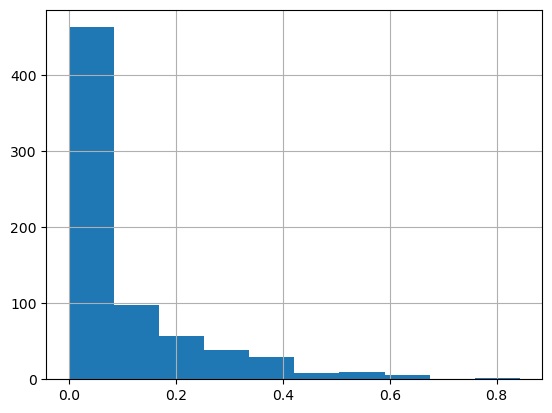

In [45]:
glofas5_enriched[glofas5_enriched["glacier_frac"]>0]["glacier_frac"].hist()

In [46]:
# save the results
glofas5_enriched.to_csv("GloFASv5_Stations_Overview_260223/GloFASv5_catchments_glaciers_comprehensive.csv", index=False)